# Notebook - Find best Drug compound for Ebola virus

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [184]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [185]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from copy import deepcopy

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [186]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [187]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [188]:
allVirusData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')

### Filter columns and keeping only data for Ebola virus

In [189]:
allVirusData_chEMBL_wMACAW =  allVirusData_chEMBL_wMACAW.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
EbolaVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW[allVirusData_chEMBL_wMACAW['Virus'] == 'Ebola']
EbolaVirusData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
13073,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,100.00,NaN,Ebola
13074,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,0.32,NaN,Ebola
13075,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,1.88,5.725842,Ebola
13076,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,2.49,5.603801,Ebola
13077,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,50.00,NaN,Ebola
...,...,...,...,...,...
13794,CHEMBL5591747,CCN1CCN(CCCC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)...,5.30,5.275724,Ebola
13795,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,34.00,NaN,Ebola
13796,CHEMBL221722,NC(=O)c1nc(F)cnc1O,61.88,4.208450,Ebola
13797,CHEMBL5595942,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCN1CCOCC1,34.00,NaN,Ebola


### Rename columns

In [190]:
EbolaVirusData_chEMBL_wMACAW = EbolaVirusData_chEMBL_wMACAW.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "Virus" : "VirusClassifier",
})

### Compound Distribution Across Viruses

In [191]:
virus_counts = EbolaVirusData_chEMBL_wMACAW['VirusClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(EbolaVirusData_chEMBL_wMACAW)

print(f"\n{'Virus':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Virus                               Count   Percentage
----------------------------------------------------------------------
Ebola                                 726      100.00%
----------------------------------------------------------------------
TOTAL                                 726      100.00%

Number of unique viruses: 1


### Add `ID` column to left

In [192]:
EbolaVirusData_chEMBL_wMACAW.insert(0, 'ID', range(1, len(EbolaVirusData_chEMBL_wMACAW) + 1))
EbolaVirusData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,value_uM,pPotency,VirusClassifier
13073,1,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,100.00,NaN,Ebola
13074,2,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,0.32,NaN,Ebola
13075,3,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,1.88,5.725842,Ebola
13076,4,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,2.49,5.603801,Ebola
13077,5,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,50.00,NaN,Ebola


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `VirusClassifier`

In [193]:
EbolaVirusData_chEMBL_wMACAW = EbolaVirusData_chEMBL_wMACAW.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "VirusClassifier"]
)
EbolaVirusData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier
13073,1,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,NaN,Ebola
13074,2,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,NaN,Ebola
13075,3,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842,Ebola
13076,4,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801,Ebola
13077,5,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,NaN,Ebola


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [194]:
print("Original shape:", EbolaVirusData_chEMBL_wMACAW.shape)

EbolaVirusData_chEMBL_wMACAW = EbolaVirusData_chEMBL_wMACAW[EbolaVirusData_chEMBL_wMACAW['pPotency'].notna() 
    & (EbolaVirusData_chEMBL_wMACAW['pPotency'] > 0) ]   # & (EbolaVirusData_chEMBL_wMACAW['pPotency'] < 12)

print("Shape after cleaning 'pPotency' value:", EbolaVirusData_chEMBL_wMACAW.shape)

Original shape: (726, 5)
Shape after cleaning 'pPotency' value: (647, 5)


In [195]:
EbolaVirusData_chEMBL_wMACAW

,ID,compound_id,Smiles,pPotency,VirusClassifier
13075,3,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842,Ebola
13076,4,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801,Ebola
13080,8,CHEMBL5084473,CCC(CC)COC(=O)[C@@H](C)N[P@](=O)(OC[C@H]1O[C@@...,6.080922,Ebola
13081,9,CHEMBL2323050,N#Cc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3...,5.096910,Ebola
13082,10,CHEMBL2323047,COc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3)...,5.267606,Ebola
...,...,...,...,...,...
13792,720,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,5.494850,Ebola
13793,721,CHEMBL5594689,CC1(C)[C@@H]2CC[C@@]1(CS(=O)(=O)N1CCOCC1)C(=O)C2,6.045757,Ebola
13794,722,CHEMBL5591747,CCN1CCN(CCCC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)...,5.275724,Ebola
13796,724,CHEMBL221722,NC(=O)c1nc(F)cnc1O,4.208450,Ebola


### Remove duplicate compounds using Compute median potency per (Smiles, Virus) pair

In [196]:
duplicates = EbolaVirusData_chEMBL_wMACAW.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 191


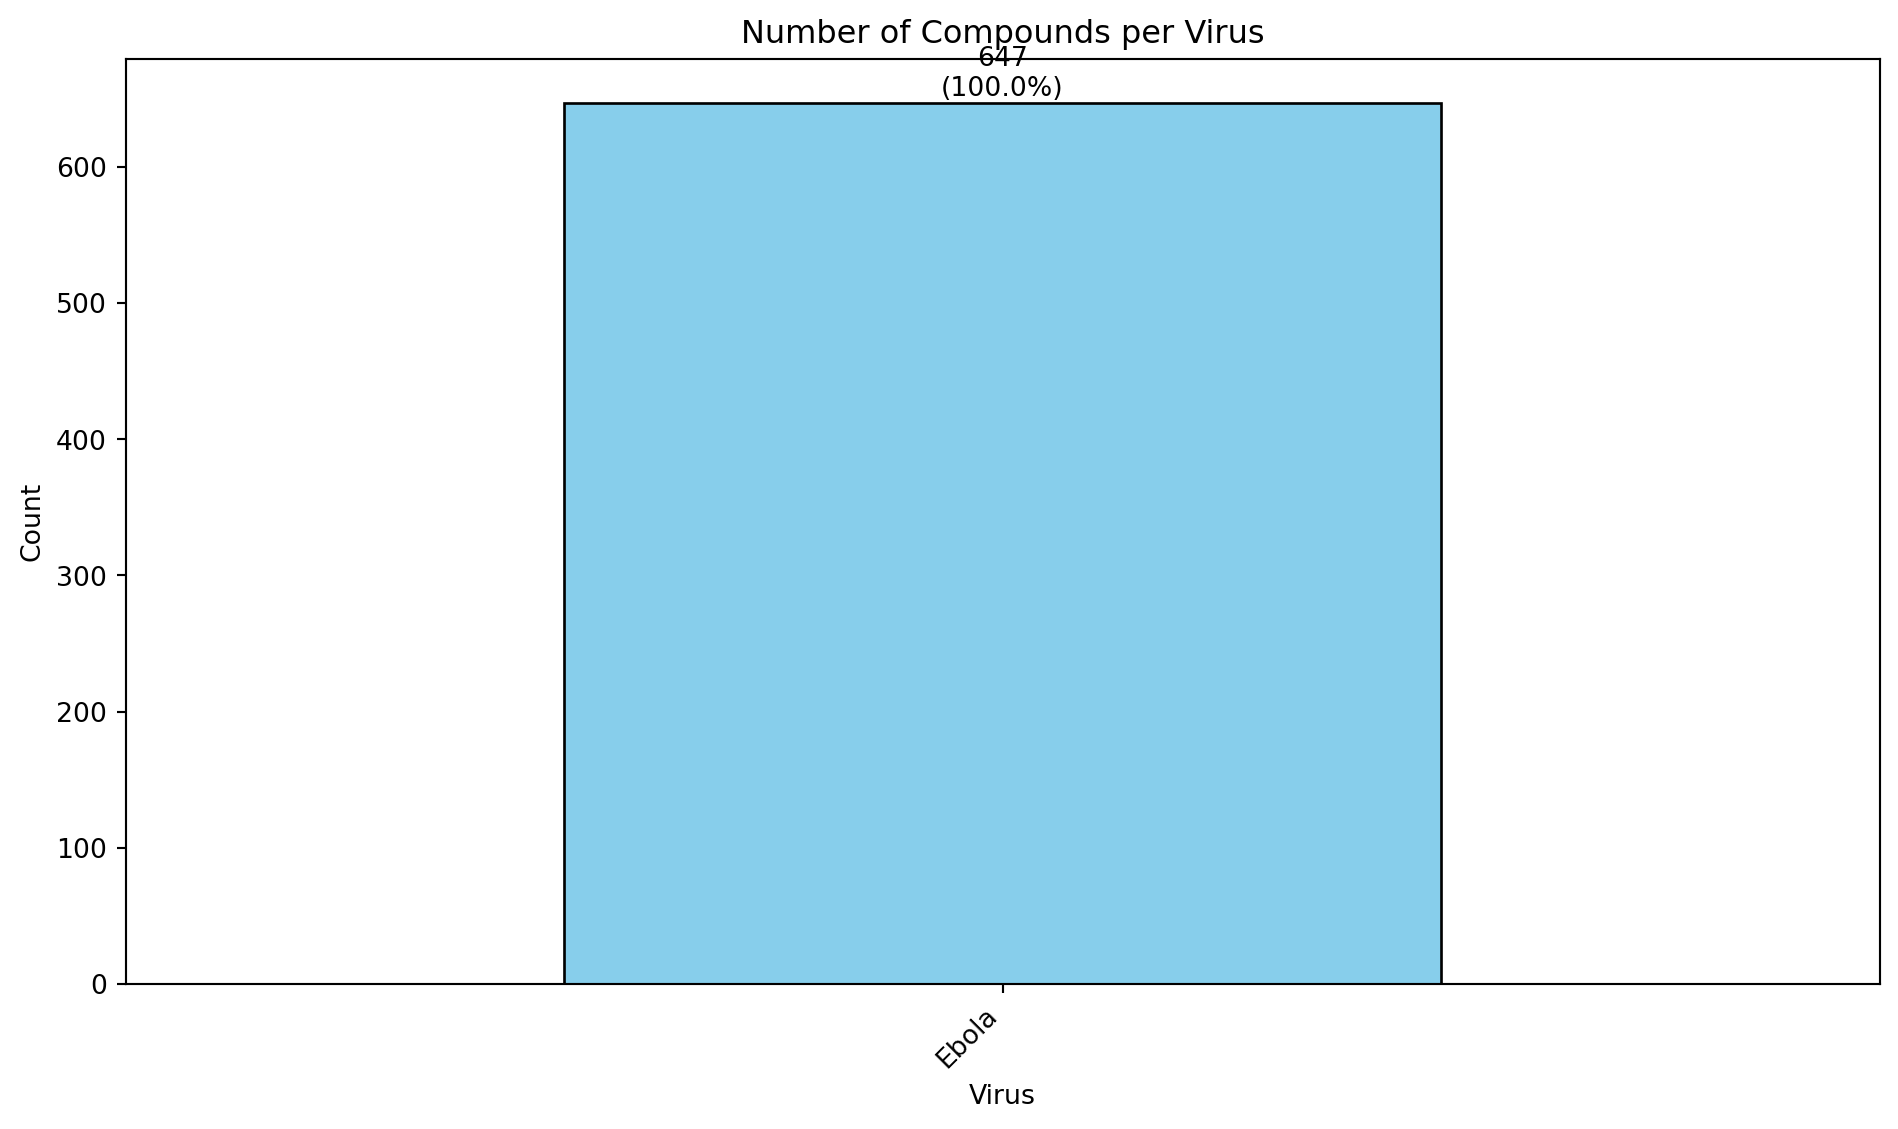

In [197]:
# Get counts and percentages
counts = EbolaVirusData_chEMBL_wMACAW['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [198]:
EbolaVirusData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "EbolaVirusData_chEMBL_wMACAW_MLready.csv"), index=False)

### pPotency value distribution across each Virus

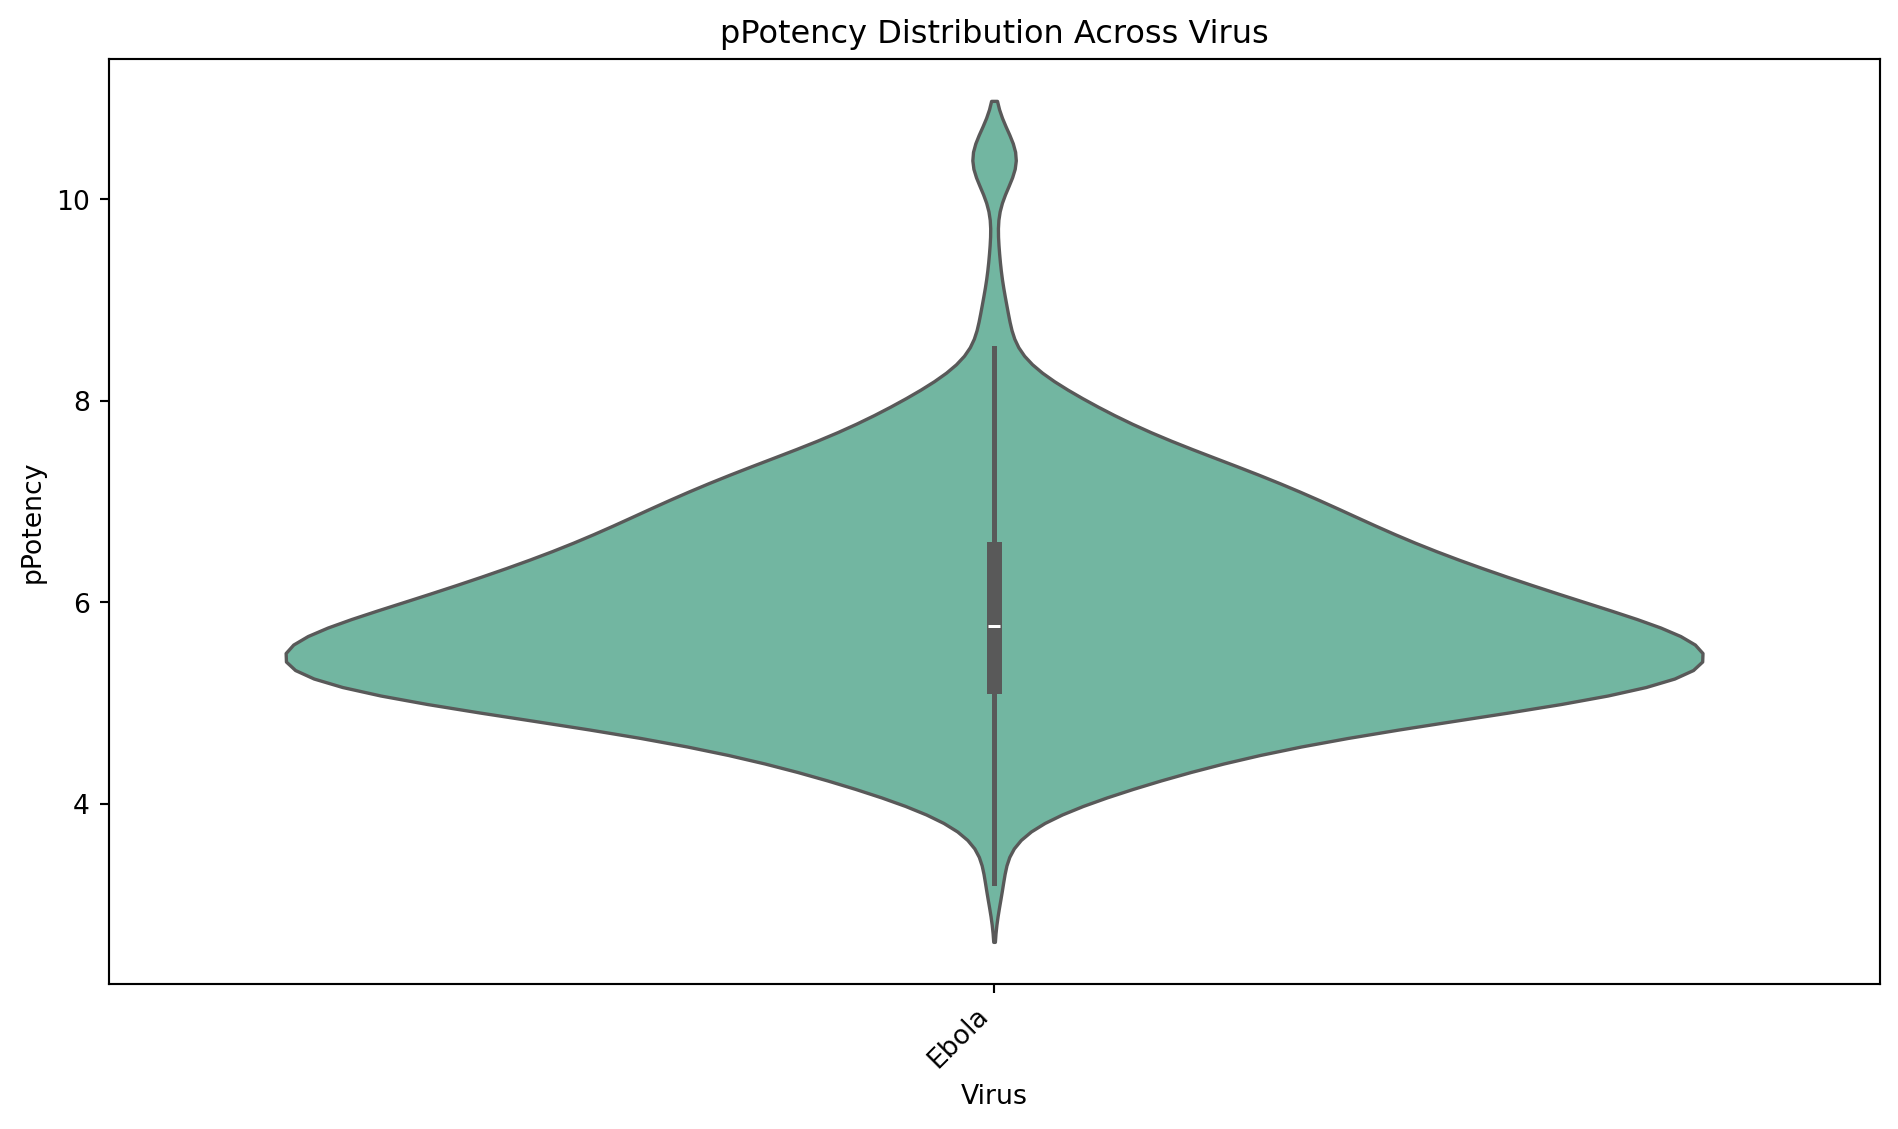

In [199]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=EbolaVirusData_chEMBL_wMACAW_ordered,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

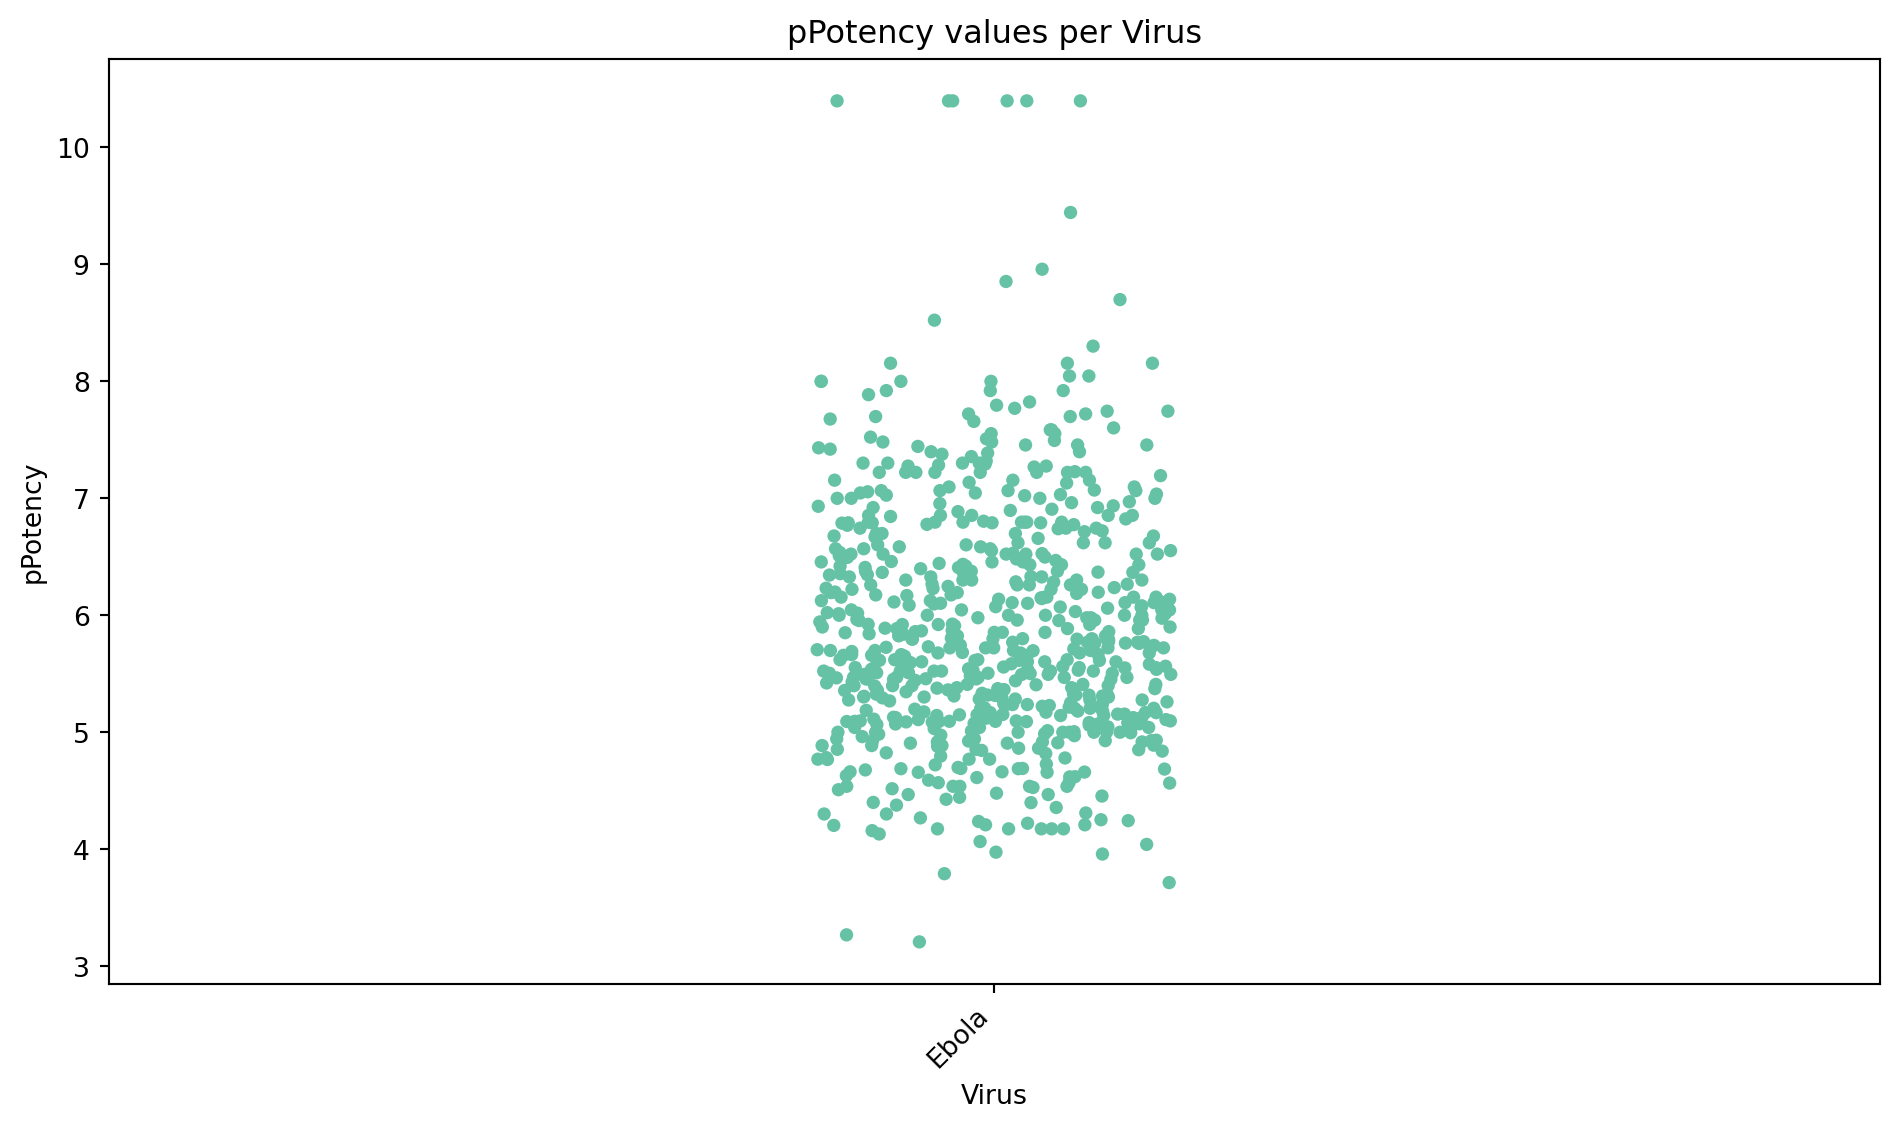

In [200]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=EbolaVirusData_chEMBL_wMACAW_ordered,
    x='VirusClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [201]:
# df = EbolaVirusData_chEMBL_wMACAW
Y = EbolaVirusData_chEMBL_wMACAW.pPotency
smiles = EbolaVirusData_chEMBL_wMACAW.Smiles

In [202]:
print(len(smiles))

647


### Normalize the potency data
$$
\begin{align}
\text{value (M)} &= \text{value}_{\mu M} \times 10^{-6} \\
p\text{Potency} &= -\log_{10}(\text{value (M)}) \\
&= 6 - \log_{10}(\text{value}_{\mu M})
\end{align}
$$

so, $$ p\text{Potency} = 6 - \log_{10}(\text{value}_{\mu M}) $$

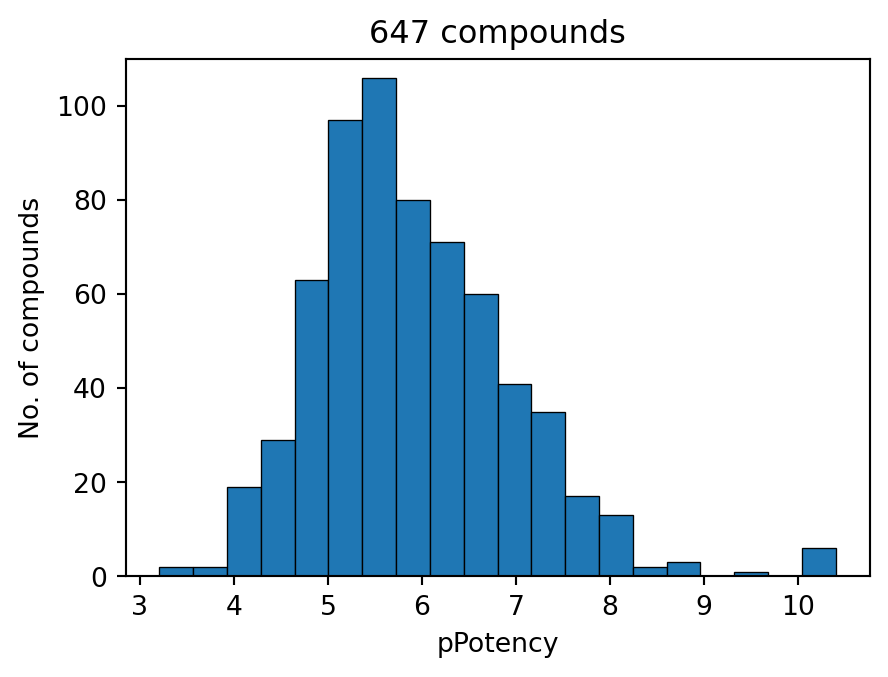

In [203]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [204]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [205]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [206]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [207]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 647 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### Create directory to save plot

In [208]:
save_path = resultsDir + 'Ebolavirus/EbolaVirus_CV_testOnly.svg'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

### ML predictions with Train + Test results

In [209]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.37
  RMSE: 0.54
  R²:   0.74
Test Set:
  MAE:  0.47
  RMSE: 0.66
  R²:   0.61

Best params (sample): [{'C': 30, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 5, 'epsilon': 0.1, 'kernel': 'rbf'}]
CPU times: user 241 ms, sys: 61.5 ms, total: 302 ms
Wall time: 11.7 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Ebolavirus/EbolaVirus_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Ebolavirus/EbolaVirus_CV_TrTs.png


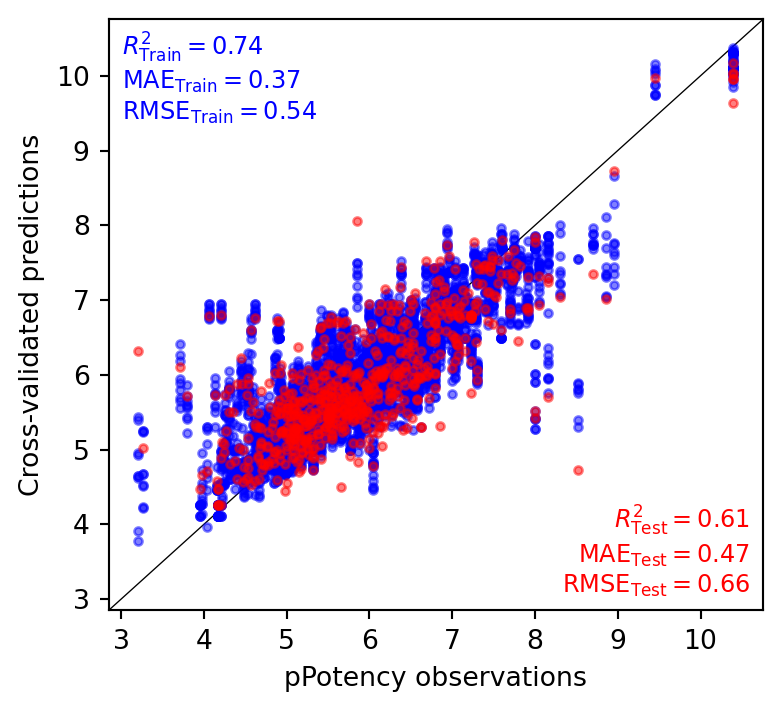

In [210]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Ebolavirus/EbolaVirus_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [211]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

In [212]:
X_all = mcw.transform(smiles)
X_all.shape

(647, 15)

Training samples: 517
Test samples: 130
Feature dimensions: 15

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 30
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.45

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.81            0.62            0.19           
MAE        0.29            0.45            0.16           
RMSE       0.46            0.68            0.22           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Ebolavirus/EbolaVirus_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTR

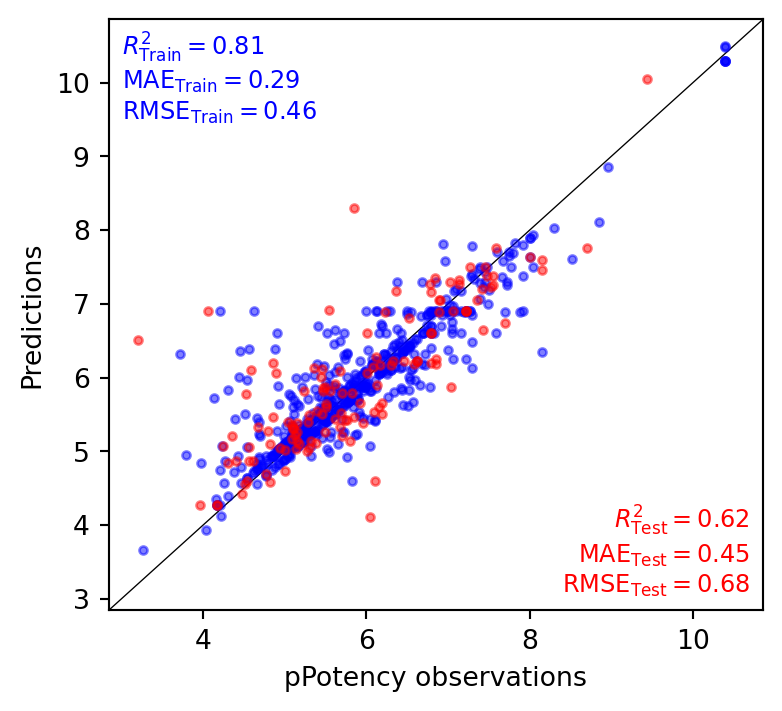

CPU times: user 958 ms, sys: 55.3 ms, total: 1.01 s
Wall time: 1.8 s


In [213]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=resultsDir + 'Ebolavirus/EbolaVirus_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2. Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [214]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

(19490, 2)


,Smiles,Source
0,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


In [215]:
smi_lib = EnamineAntiviralsData.Smiles

Generate predictions for the H1 receptor:

In [216]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

Let us represent the predictions of both models:

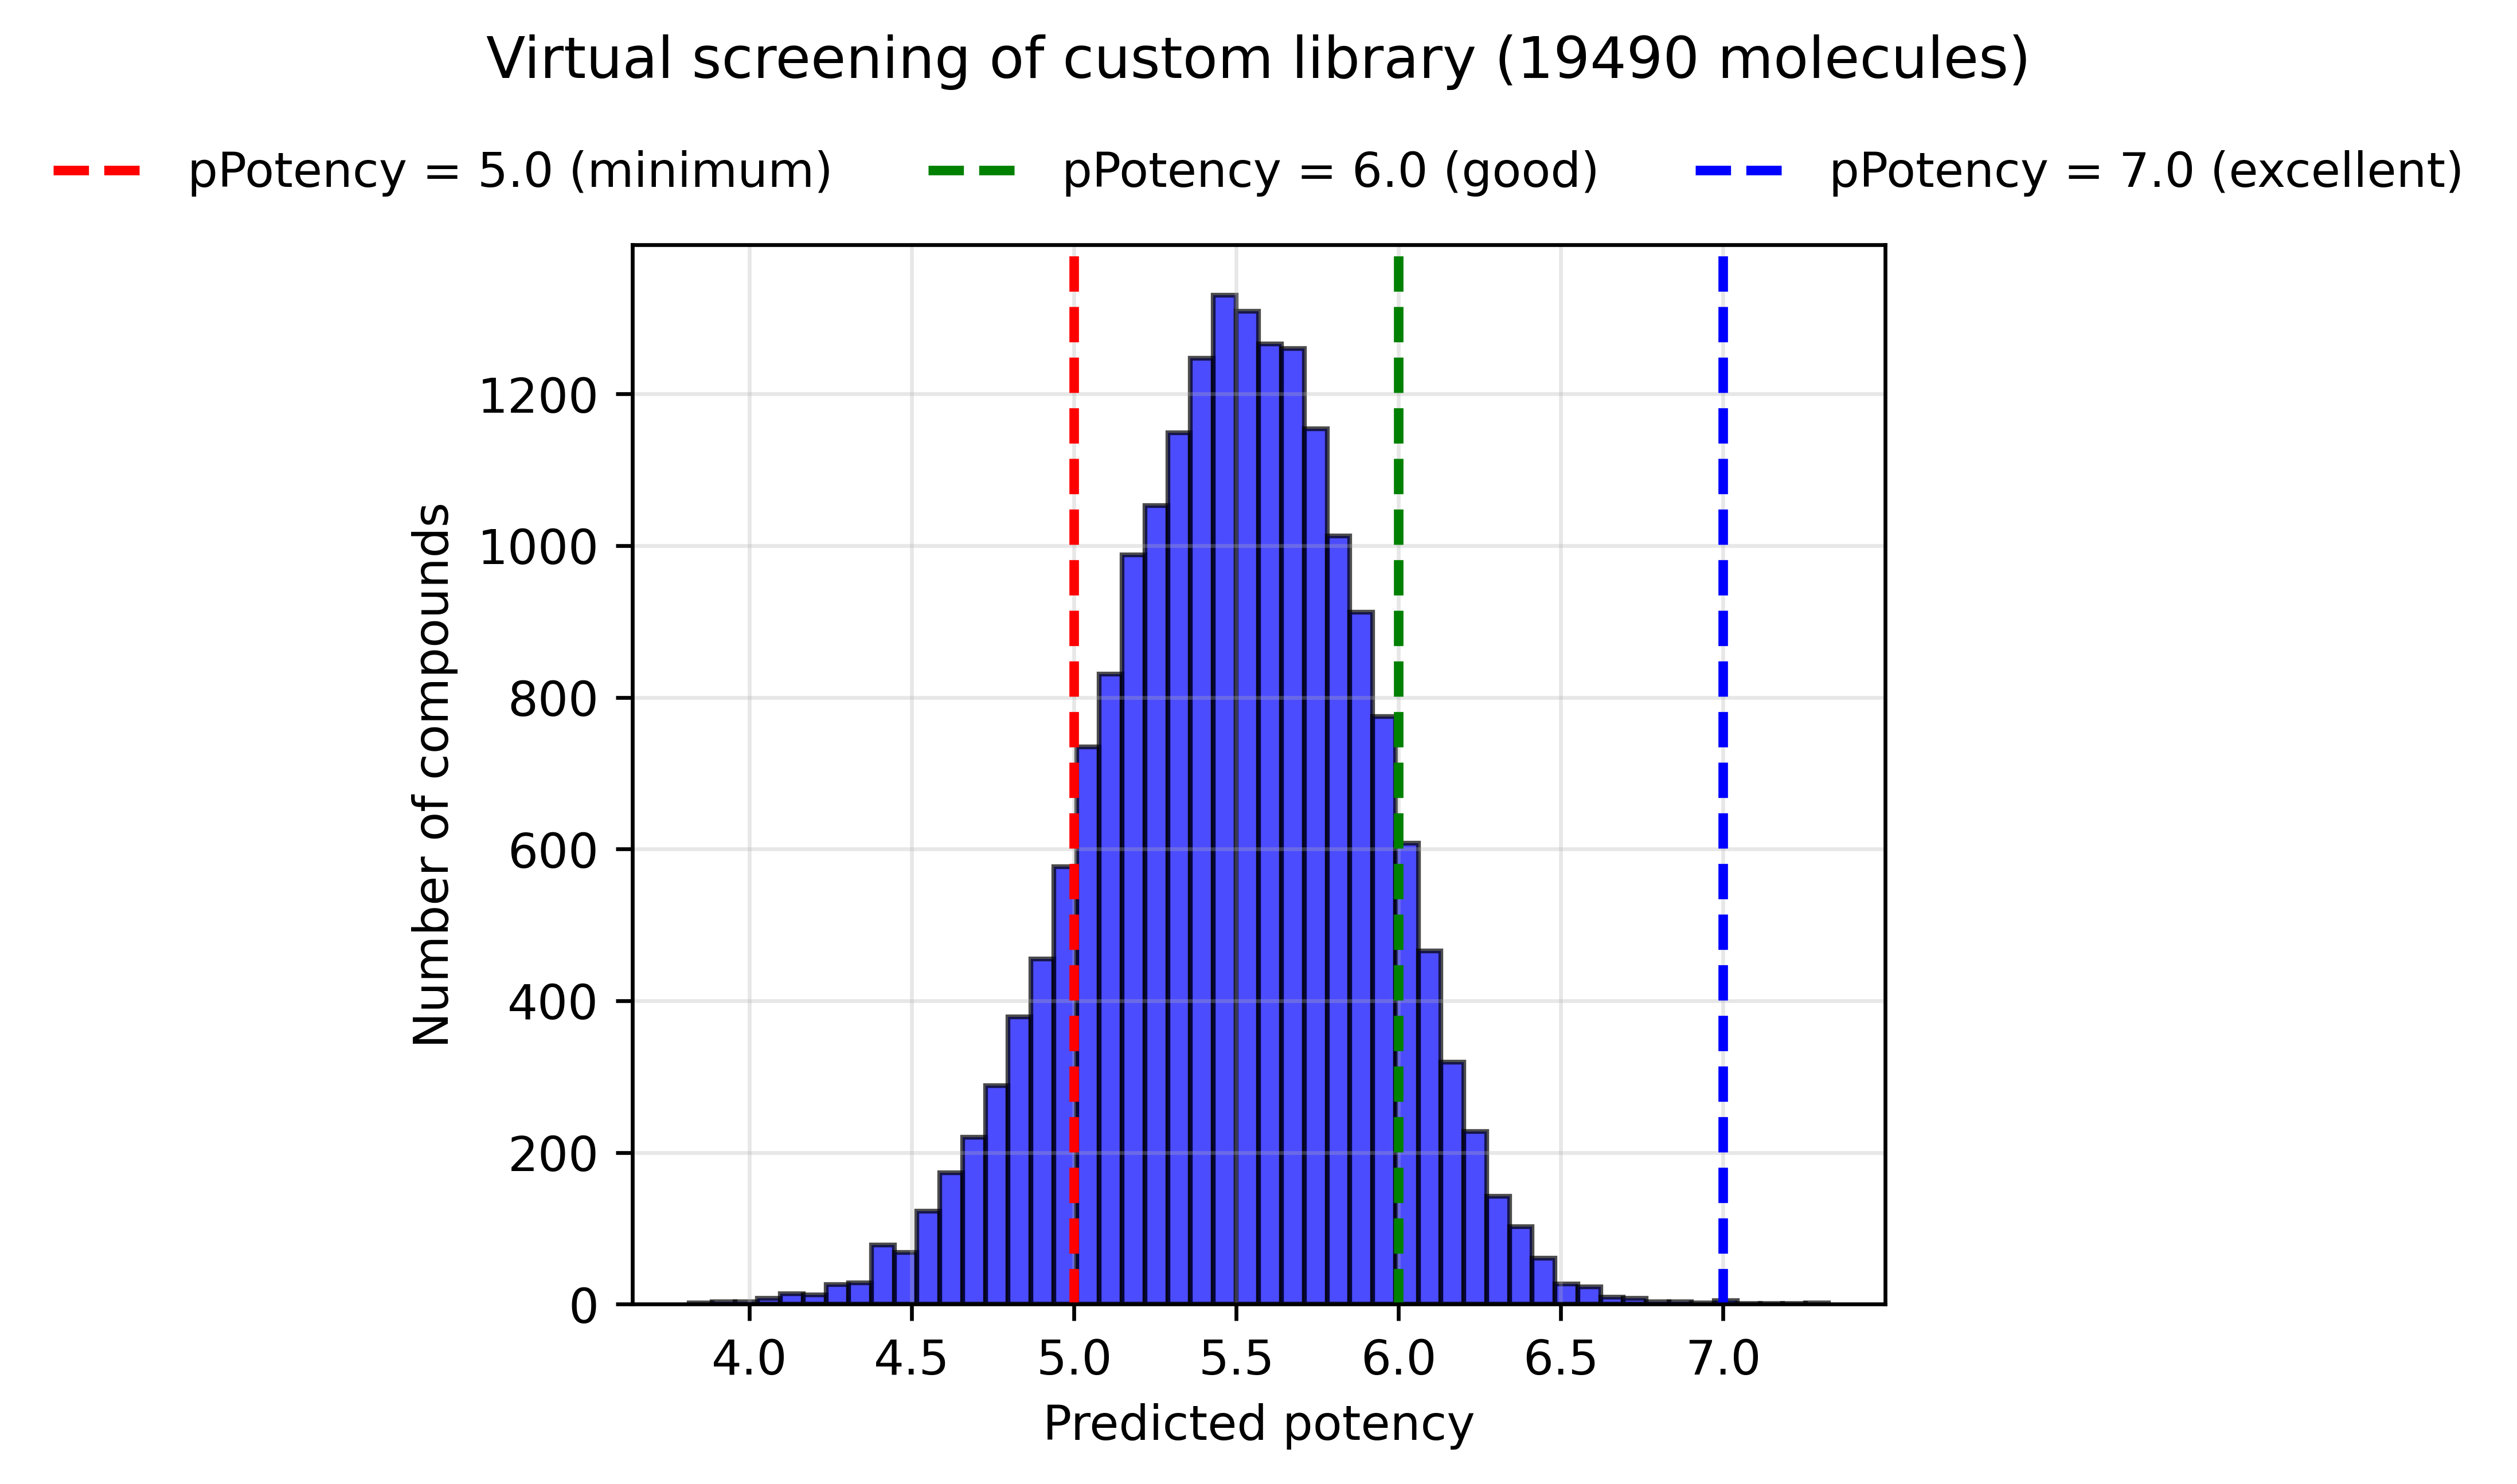

In [217]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Ebolavirus/EbolaVirus_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Ebolavirus/EbolaVirus_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [218]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 8 compounds
Medium priority (6 ≤ pPotency < 7.0): 1906 compounds
Low priority (5 ≤ pPotency < 6): 15183 compounds


In [219]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,Smiles,Source,pPotency_prediction
3712,Clc1cccc(c1)C1(CCOCC1)c1nnc(o1)c1ccc2OCCOc2c1,Enamine_DDS522,7.144779
10666,COc1cc(Cc2noc(n2)C2(Cc3ccc(F)cc3)CC2)ccc1S(=O)...,Enamine_DDS7476,7.004425
14406,CCN(CC)c1ccc(C=C2CCC(=C2N2CCOCC2)C=NN=Cc2c(C)[...,Enamine_Phenotypic,7.017135
16951,CO[C@@H]1C[C@@H](CC[C@H]1O)C=C(C)[C@H]1OC(=O)[...,Enamine_Phenotypic,7.324416
18572,CCC1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(OC)[...,Enamine_Phenotypic,7.296752
18575,CO[C@@H]1C[C@H](C[C@@H](C)[C@@H]2CC(=O)[C@H](C...,Enamine_Phenotypic,7.073837
19296,CC(C)[C@H](NC(=O)N(C)Cc1csc(n1)C(C)C)C(=O)N[C@...,Enamine_Phenotypic,7.020396
19299,CC(=O)O[C@@H]1C2=C(C)[C@H](C[C@@](O)([C@@H](OC...,Enamine_Phenotypic,7.242636


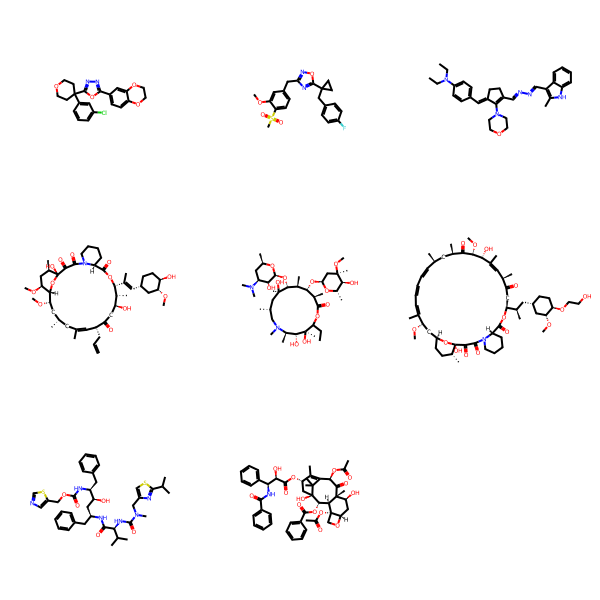

In [220]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Run the same code by removing duplicate SMILES

In [221]:
EbolaVirusData_chEMBL_wMACAW

,ID,compound_id,Smiles,pPotency,VirusClassifier
13075,3,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842,Ebola
13076,4,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801,Ebola
13080,8,CHEMBL5084473,CCC(CC)COC(=O)[C@@H](C)N[P@](=O)(OC[C@H]1O[C@@...,6.080922,Ebola
13081,9,CHEMBL2323050,N#Cc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3...,5.096910,Ebola
13082,10,CHEMBL2323047,COc1ccc(CN2CCN(C(=O)CNC(=O)CC34CC5CC(CC(C5)C3)...,5.267606,Ebola
...,...,...,...,...,...
13792,720,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,5.494850,Ebola
13793,721,CHEMBL5594689,CC1(C)[C@@H]2CC[C@@]1(CS(=O)(=O)N1CCOCC1)C(=O)C2,6.045757,Ebola
13794,722,CHEMBL5591747,CCN1CCN(CCCC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)...,5.275724,Ebola
13796,724,CHEMBL221722,NC(=O)c1nc(F)cnc1O,4.208450,Ebola


### Remove duplicate compounds using Compute median potency per (Smiles, Virus) pair

In [222]:
# Print shape before removing duplicates
print("Before removing duplicates:", EbolaVirusData_chEMBL_wMACAW.shape)

# Aggregate duplicates *within the same Virus*
aggDF = (
    EbolaVirusData_chEMBL_wMACAW.groupby(['Smiles', 'VirusClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
EbolaVirusData_chEMBL_wMACAW_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'VirusClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'VirusClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", EbolaVirusData_chEMBL_wMACAW_noDuplicates.shape)

Before removing duplicates: (647, 5)
After removing duplicates: (456, 3)


In [223]:
duplicates = EbolaVirusData_chEMBL_wMACAW_noDuplicates.duplicated(subset=['Smiles', 'VirusClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 0


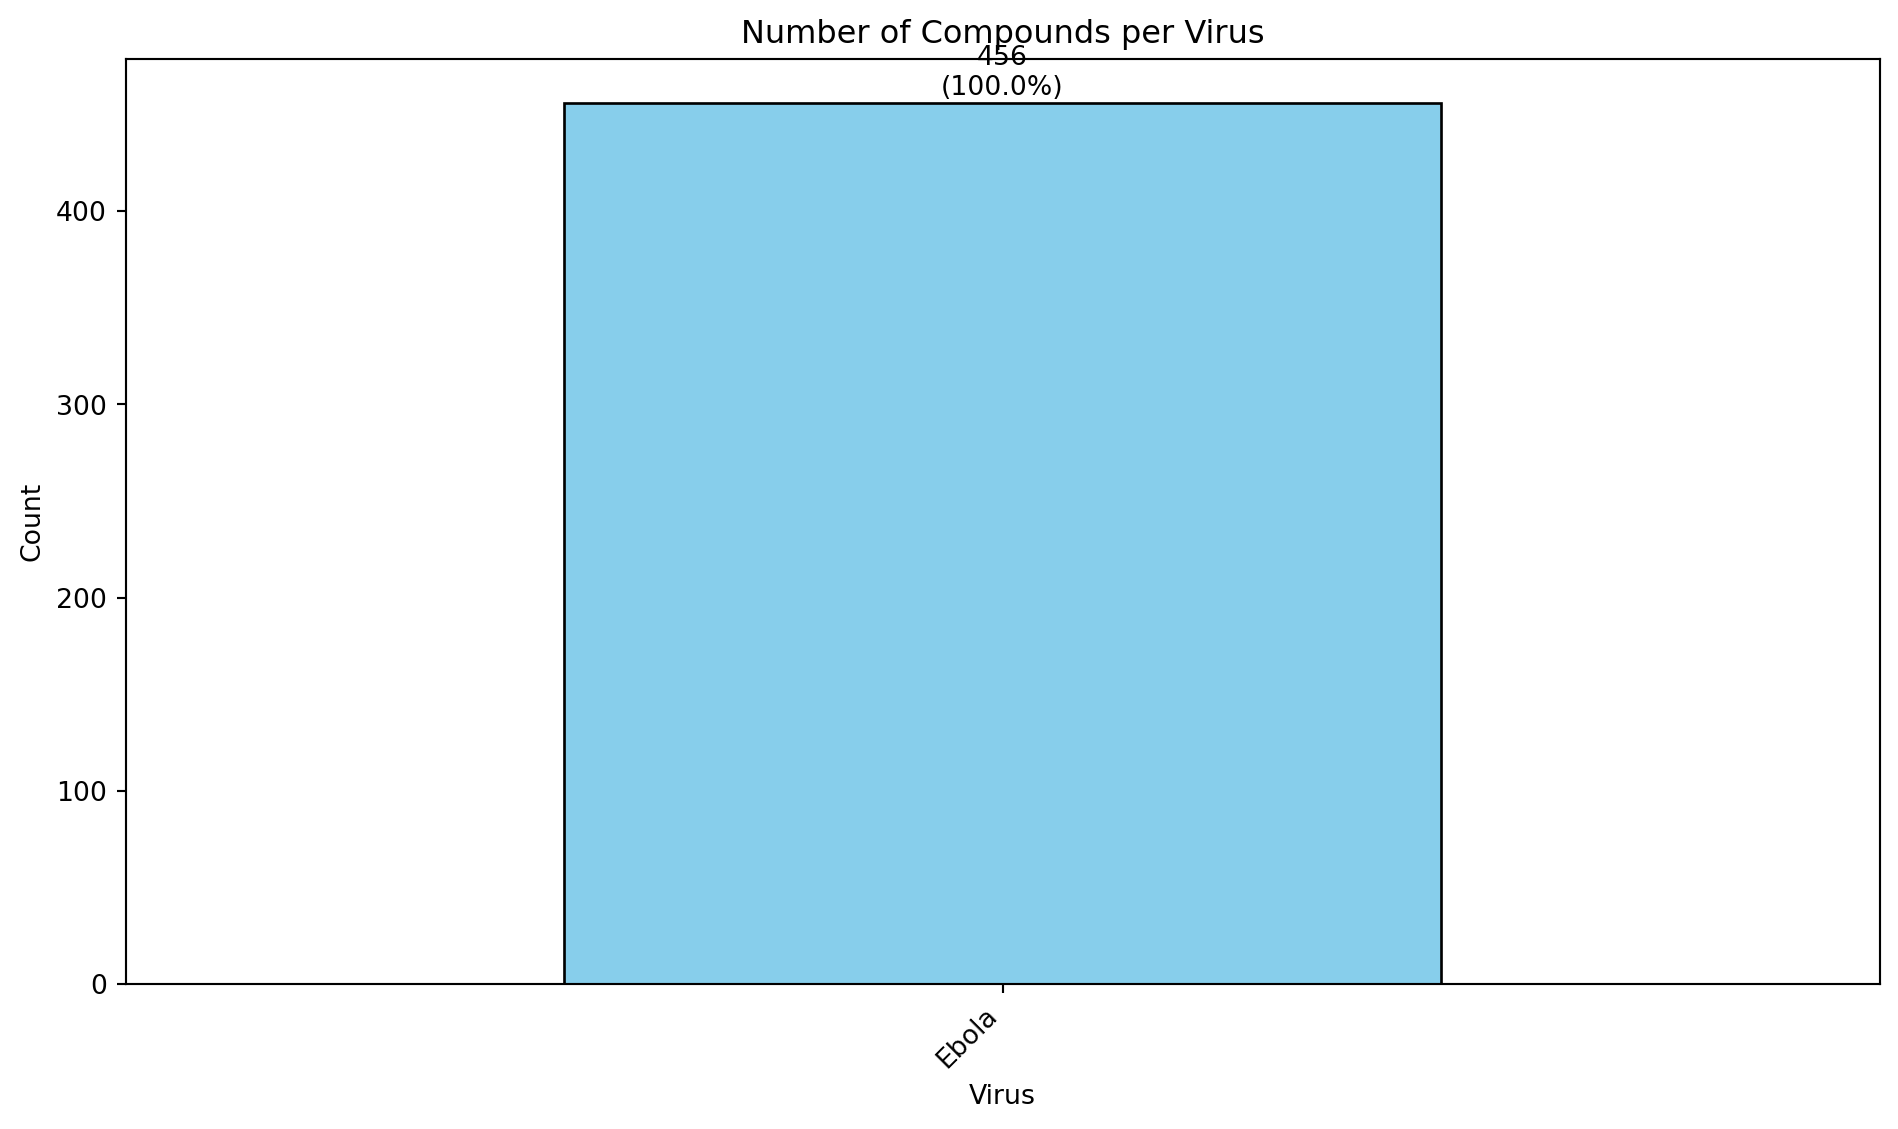

In [224]:
# Get counts and percentages
counts = EbolaVirusData_chEMBL_wMACAW_noDuplicates['VirusClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [225]:
EbolaVirusData_chEMBL_wMACAW_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "EbolaVirusData_chEMBL_wMACAW_noDuplicates_MLready.csv"), index=False)

### pPotency value distribution across each Virus

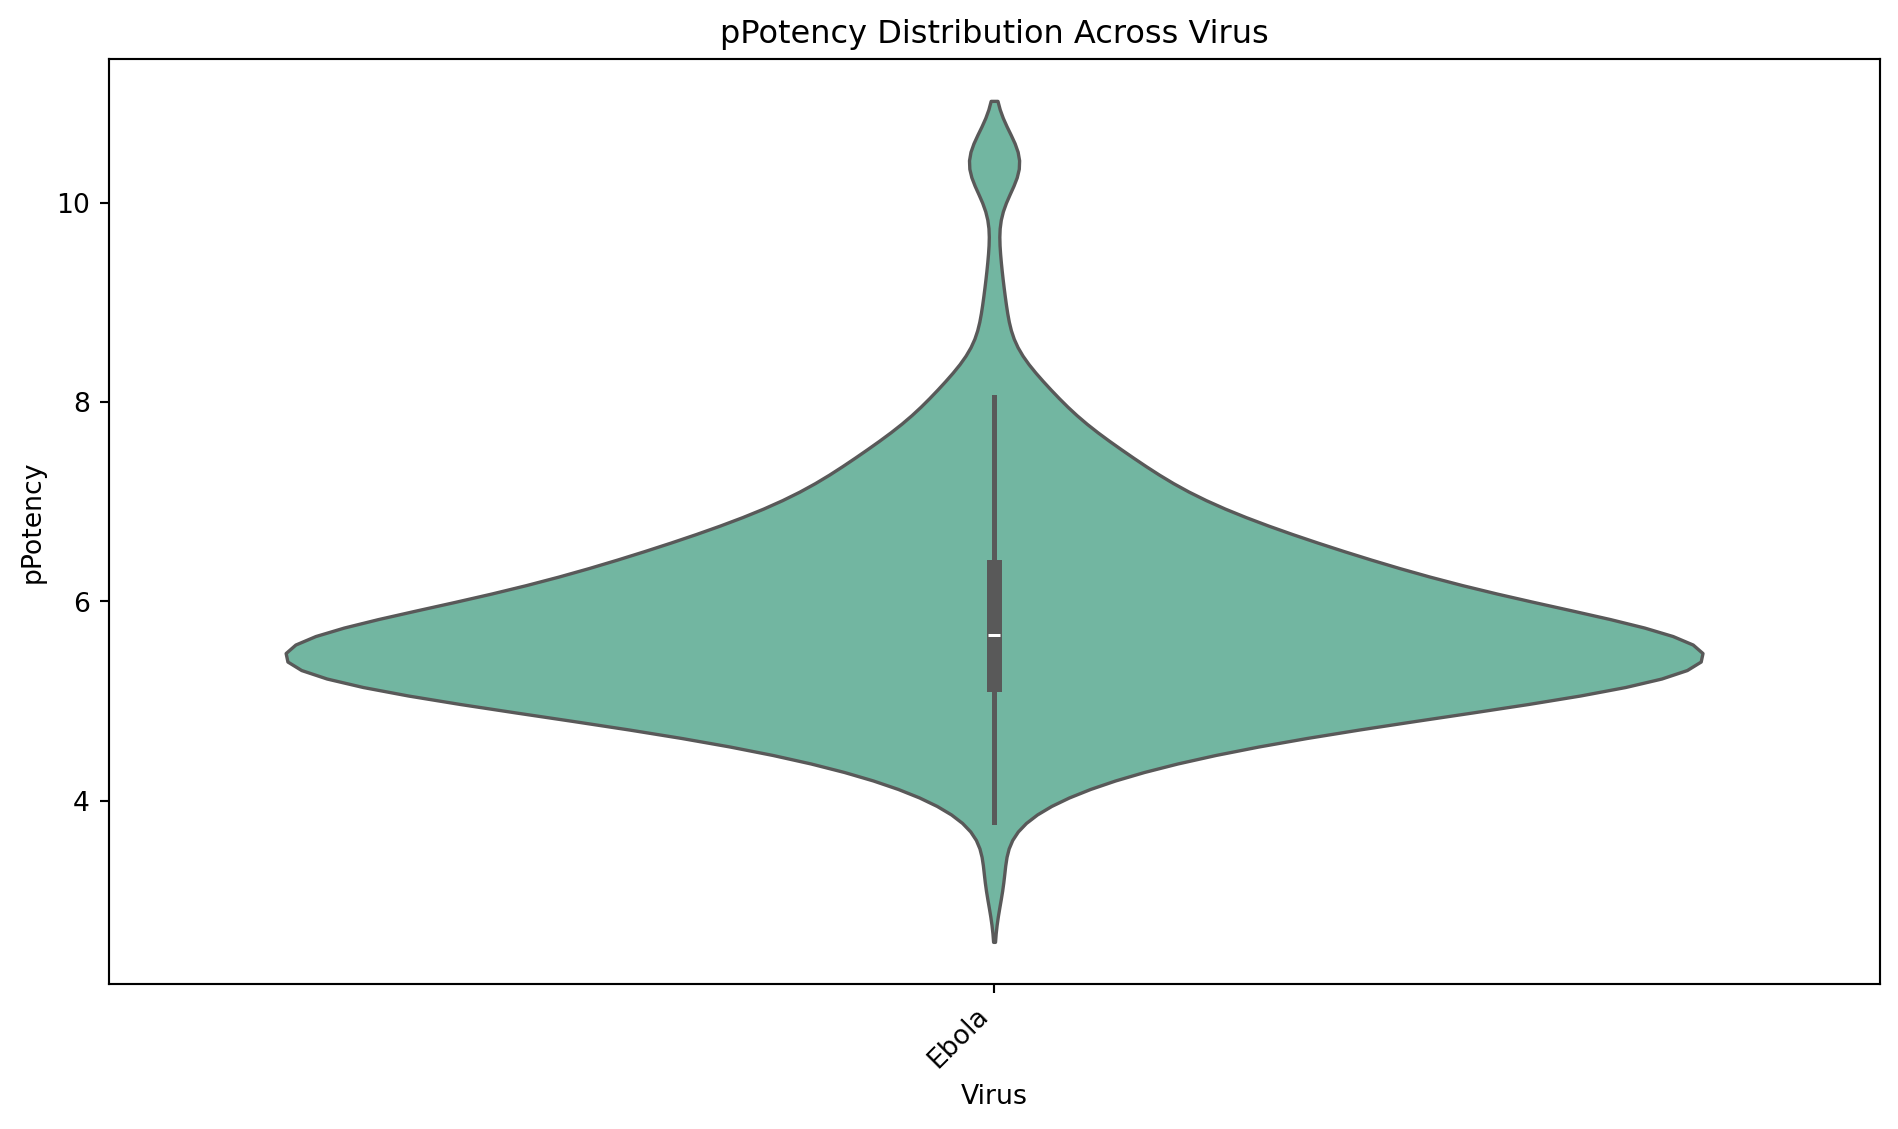

In [226]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=EbolaVirusData_chEMBL_wMACAW_noDuplicates,
    x='VirusClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

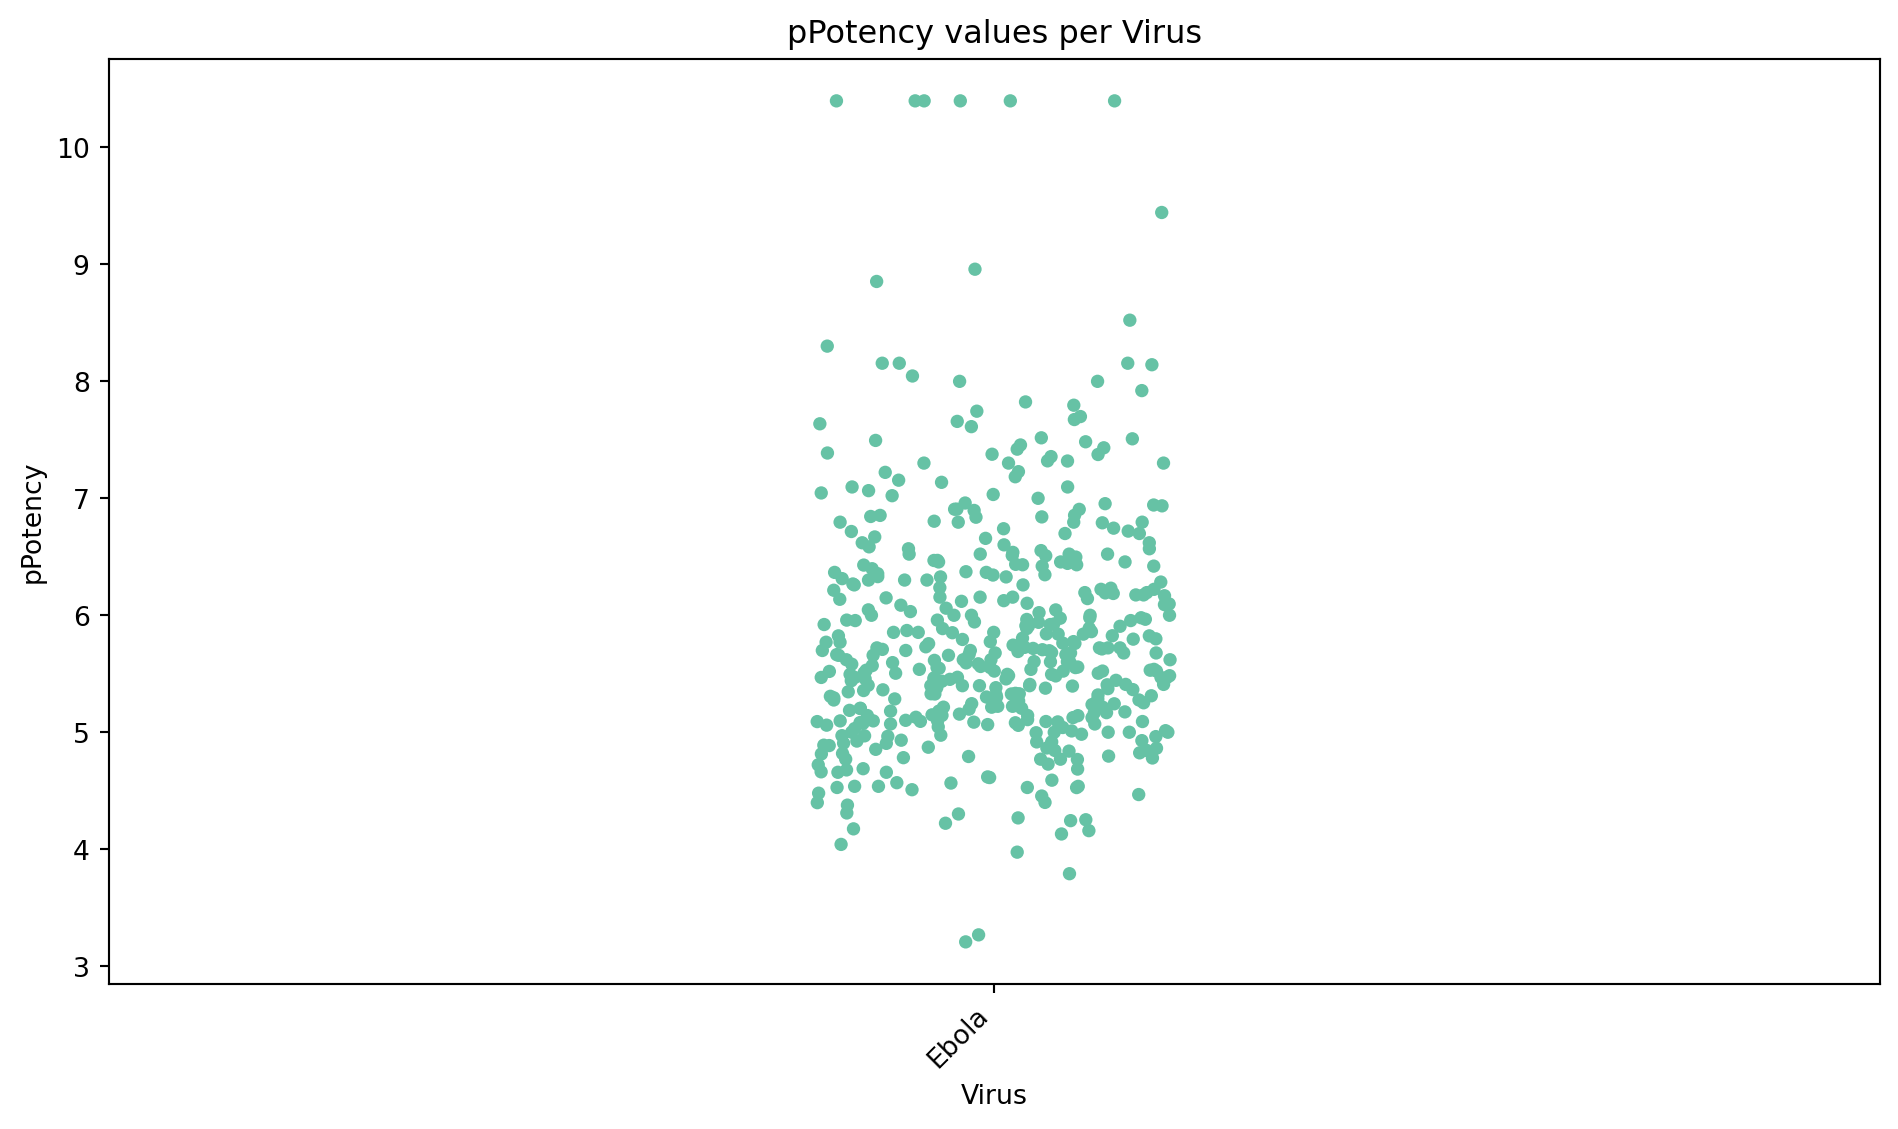

In [227]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=EbolaVirusData_chEMBL_wMACAW_noDuplicates,
    x='VirusClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [228]:
# df = EbolaVirusData_chEMBL_wMACAW_noDuplicates
Y = EbolaVirusData_chEMBL_wMACAW_noDuplicates.pPotency
smiles = EbolaVirusData_chEMBL_wMACAW_noDuplicates.Smiles

In [229]:
print(len(smiles))

456


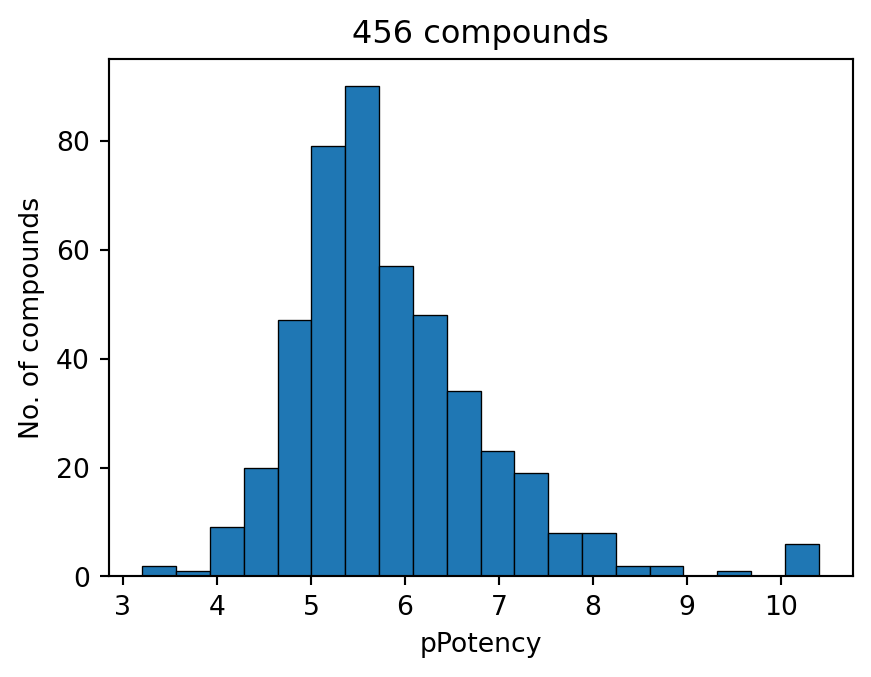

In [230]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [231]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [232]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [233]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [234]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 456 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [235]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.38
  RMSE: 0.55
  R²:   0.73
Test Set:
  MAE:  0.48
  RMSE: 0.65
  R²:   0.63

Best params (sample): [{'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}]
CPU times: user 165 ms, sys: 40.8 ms, total: 206 ms
Wall time: 5.11 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Ebolavirus/EbolaVirus_noDuplicates_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Ebolavirus/EbolaVirus_noDuplicates_CV_TrTs.png


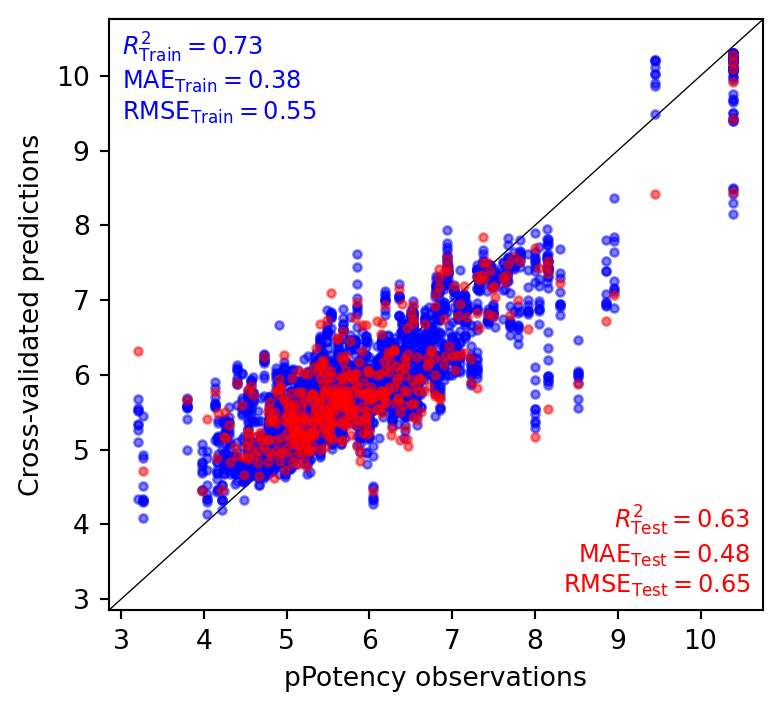

In [236]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'Ebolavirus/EbolaVirus_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [237]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

In [238]:
X_all = mcw.transform(smiles)
X_all.shape

(456, 15)

Training samples: 364
Test samples: 92
Feature dimensions: 15

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 5
  epsilon: 0.3
  kernel: rbf

Best CV MAE (on training folds): 0.51

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.78            0.64            0.14           
MAE        0.36            0.40            0.04           
RMSE       0.50            0.60            0.10           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Ebolavirus/EbolaVirus_noDuplicates_fullData_TrTs.svg
Saved: /mnt/data.ese/nfs/users/

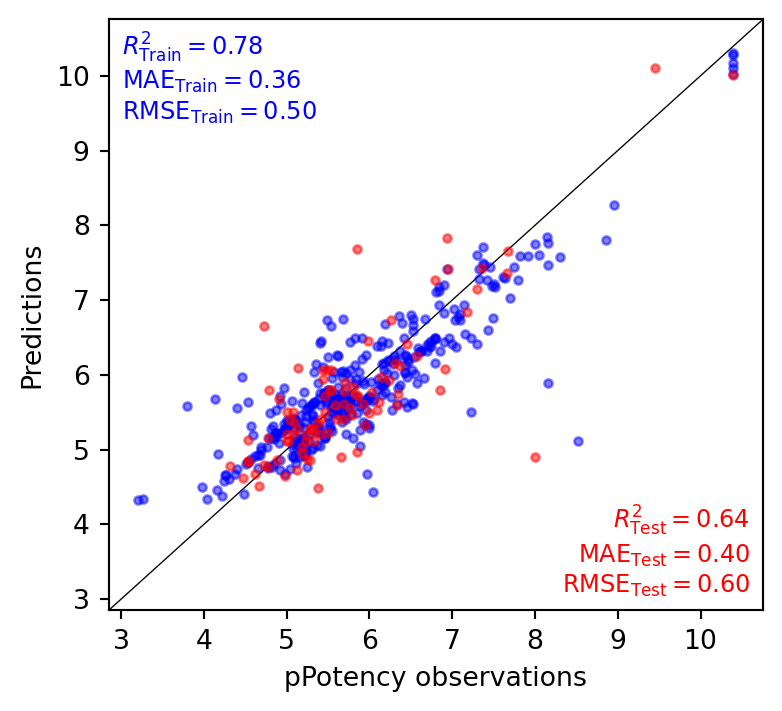

CPU times: user 860 ms, sys: 63.7 ms, total: 924 ms
Wall time: 1.1 s


In [239]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=resultsDir + 'Ebolavirus/EbolaVirus_noDuplicates_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2. Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [240]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

(19490, 2)


,Smiles,Source
0,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


In [241]:
smi_lib = EnamineAntiviralsData.Smiles

Generate predictions for the H1 receptor:

In [242]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

Let us represent the predictions of both models:

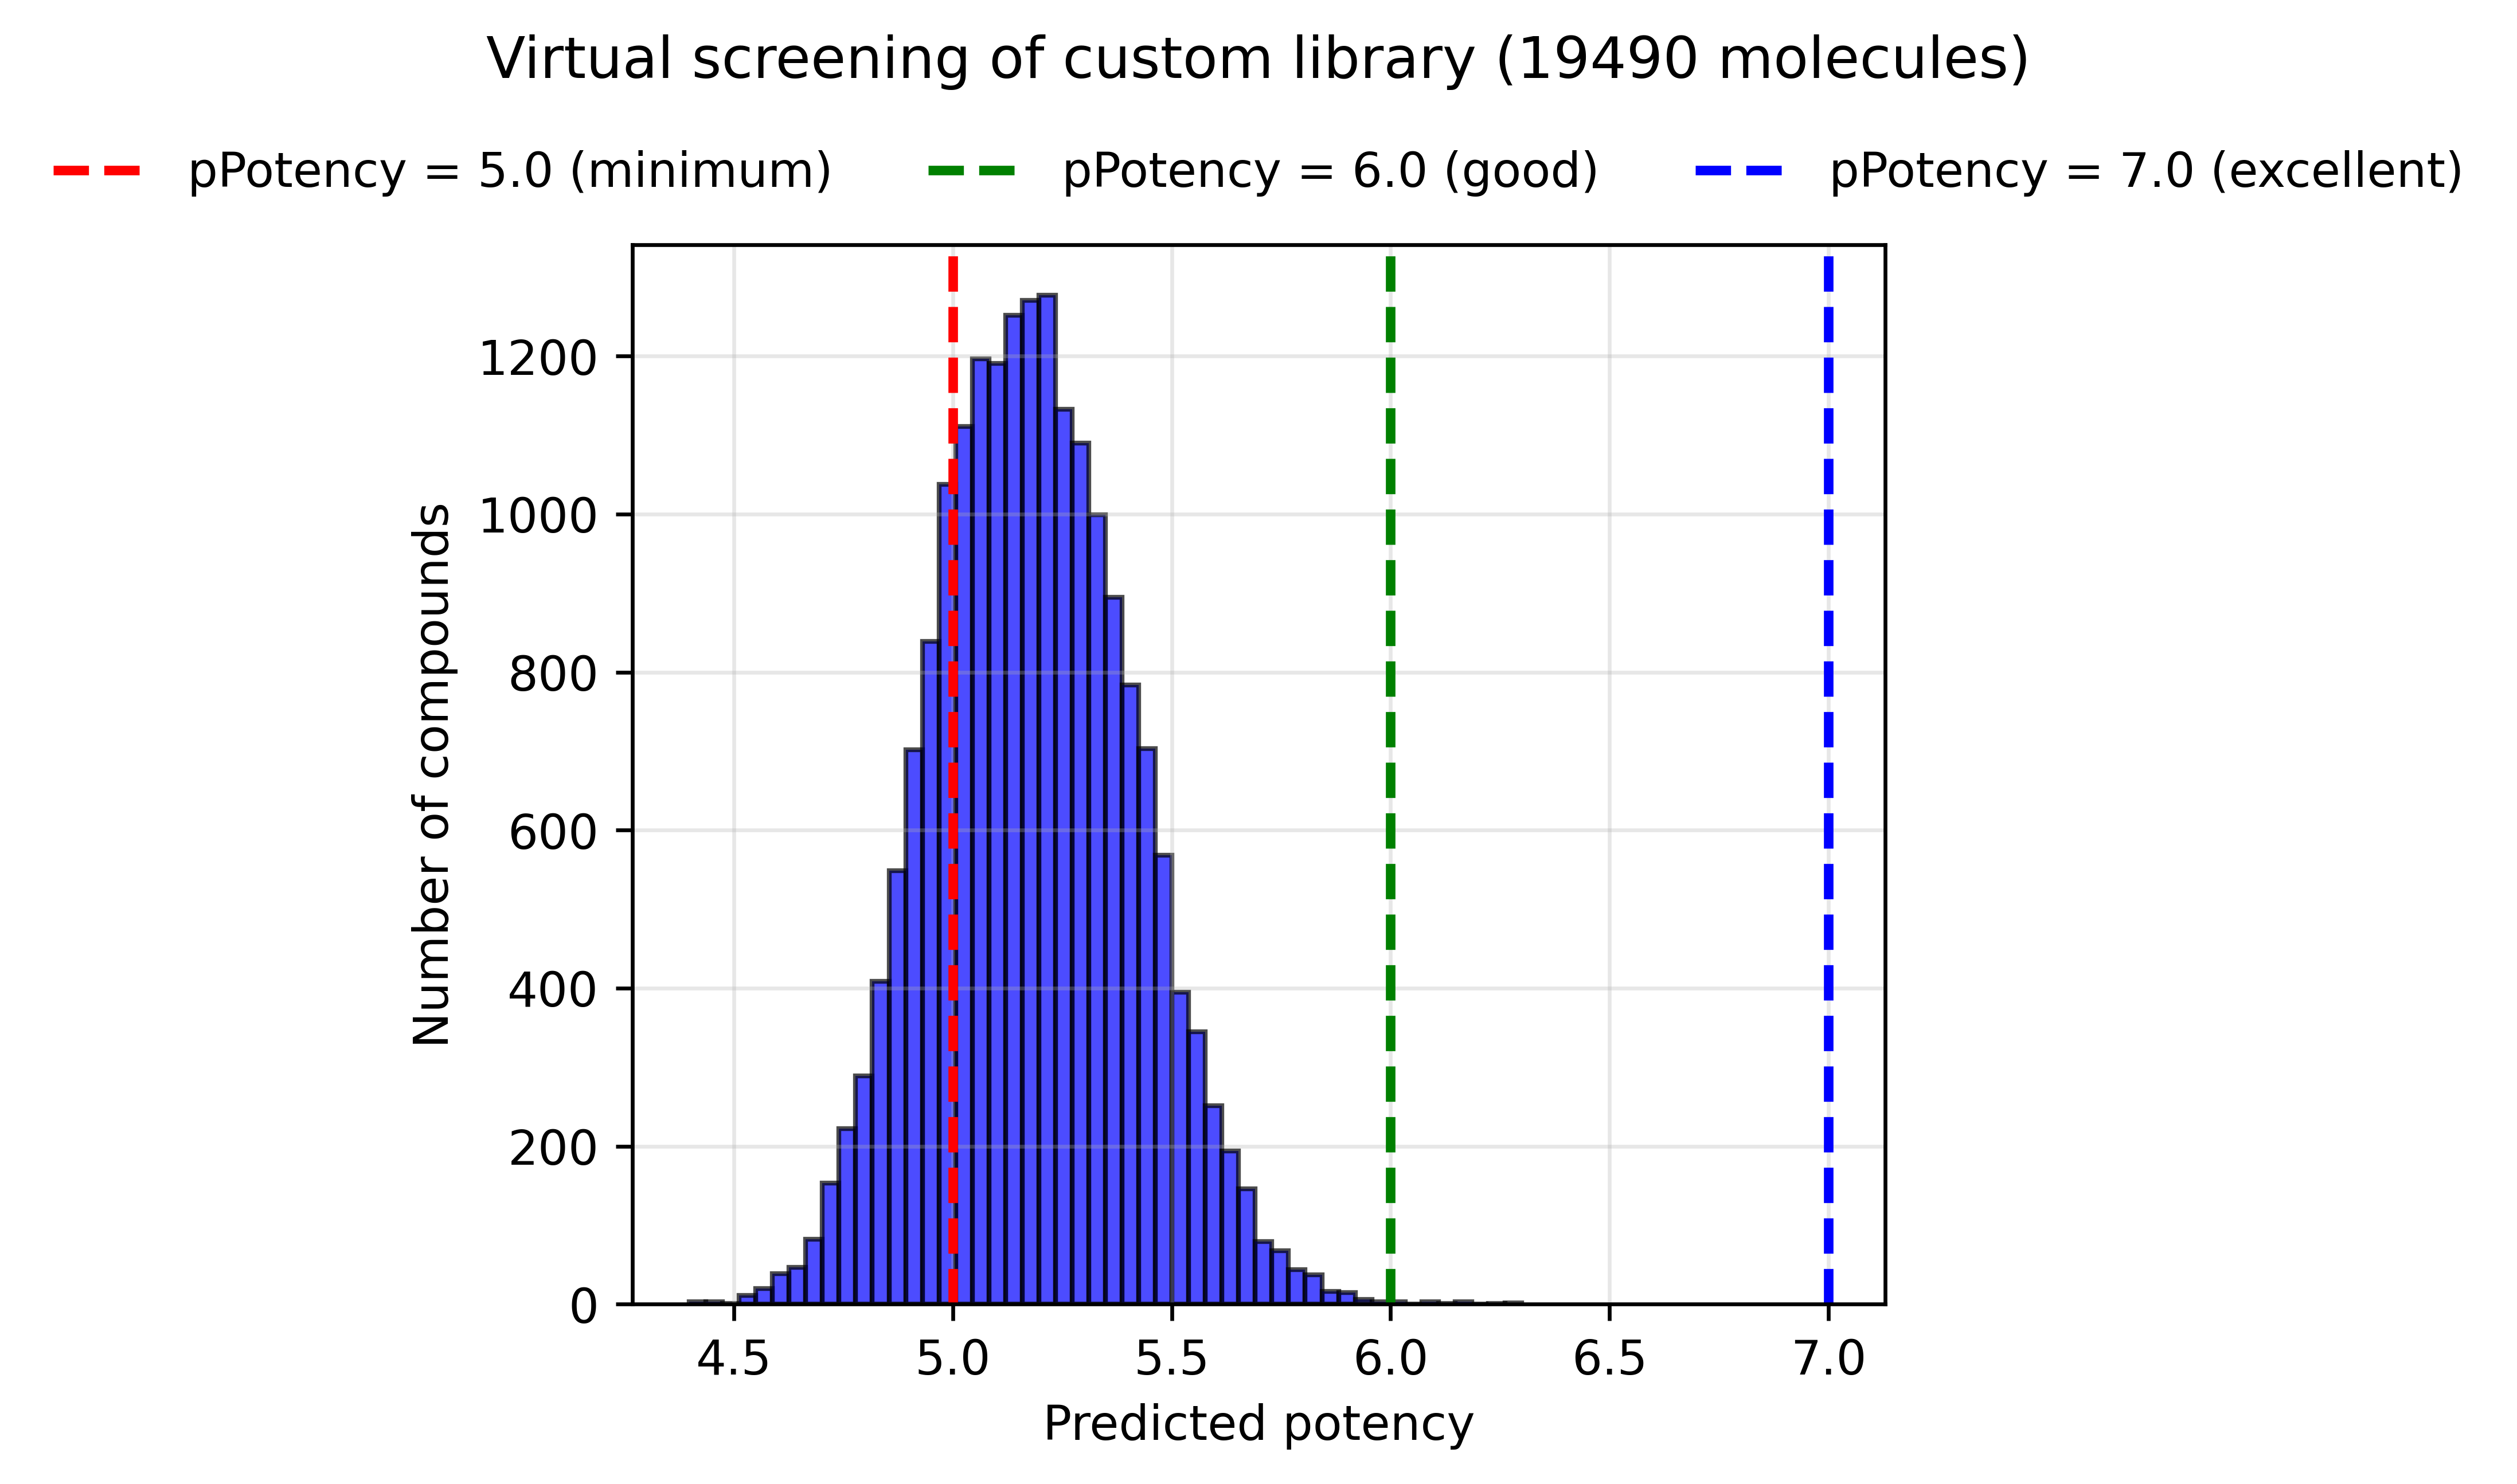

In [243]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'Ebolavirus/EbolaVirus_noDuplicates_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'Ebolavirus/EbolaVirus_noDuplicates_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [244]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 13 compounds
Low priority (5 ≤ pPotency < 6): 15225 compounds


In [245]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,Smiles,Source,pPotency_prediction


In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)